In [24]:
# English League Dataset Cleaning
### Import Dataset
### **English League Datset Overview**
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('mydata.csv')
df.head()

### **Inspect the Data Structure**
df.shape
df.info()

### **Check for Duplicate Rows**
df.duplicated().sum()
### **Standardize the column names**
#### *Column names before standardization*
df.columns
#### *Column names after standardization*
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns
### **Convert 'date' to datetime**
from dateutil import parser
df['date'] = df['date'].apply(lambda x: parser.parse(x, dayfirst=True) if pd.notnull(x) else pd.NaT)
# verify conversion
df['date'].dtype
#### Check for failed conversions
df['date'].isnull().sum()
#### *Extract Year*
df['year'] = df['date'].dt.year
#### *Extract Month*
df['month'] = df['date'].dt.month
#### *Extract Day*
df['day'] = df['date'].dt.day
#### *Create 'Season' Variable*
df['season'] = df['year'].astype(str) + "-" + (df['year'] + 1).astype(str)
##### Qucik verify of year, month,day,season columns
df[['date','year','month','day','season']].head()
df[['date','year','month','day','season']].tail()
### **Clean 'attendance'**
df['attendance'] = df['attendance'].str.replace(',', '', regex=False)
df['attendance'] = pd.to_numeric(df['attendance'], errors='coerce')

# verify conversion
df['attendance'].dtype
### **Convert home_team and away_team from numerical to categorical** - ***LOGISTIC REGRESSION MODELING ONLY/ NOT NEEDED FOR RANDOM FOREST OR XGBOOST MODELING!***
df['home_team'] = df['home_team'].astype('category')
df['away_team'] = df['away_team'].astype('category')
#### *Then one-hot encode* (Only before modeling)
df = pd.get_dummies(df, columns=['home_team', 'away_team'], drop_first=True)
### **Drop the 'links' column**
df = df.drop(columns=['links'])
### **Inspect the class column**
df['class'].value_counts()
### Not sure if we want to keep this or drop the 'class' variable due to it containing match outcomes, and can thus lead to data leakage. We would need to drop home_goals and away_goals from predictors to prevent data leakage. Or we could drop class alltogether - Will leave this to the person the discretion of whoever is perfroming predictive modeling***
#### *Code to Drop Class if needed (Optional)*
df = df.drop(columns=['class'])
### **Final cleaning check**
df.info()
### **Create target variables (for predictive modeling)**
#### *Predicting match outcomes:* 'result' target variable
df['result'] = df.apply(
    lambda x: 'home_win' if x['goals_home'] > x['away_goals']
    else ('away_win' if x['goals_home'] < x['away_goals'] else 'draw'),
    axis=1
)

# Or encode:
df['result_encoded'] = df['result'].map({
    'home_win': 0,
    'draw': 1,
    'away_win': 2
})
#### *Tests home advantage:* Home_Win_Binary
df['home_win_binary'] = (df['goals_home'] > df['away_goals']).astype(int)
#### *Analyze away team performance:* Away_Win_Binary
df['away_win_binary'] = (df['away_goals'] > df['goals_home']).astype(int)
#### *Predict draws:* Draw_Binary
df['draw_binary'] = (df['goals_home'] == df['away_goals']).astype(int)
#### *Supports performance analysis:* Close_Match (Competitiveness)
df['close_match'] = (abs(df['goals_home'] - df['away_goals']) <= 1).astype(int)
### **Create Difference Feaures**
#### *Tests whether higher possesions lead to winning:* Possesion_Difference
df['possession_diff'] = df['home_possessions'] - df['away_possessions']
#### *Tests attacking performance:* Shots_Difference
df['shots_diff'] = df['home_shots'] - df['away_shots']
#### *Tests Shots on Target:* Shots_On_Target_Difference
df['shots_on_target_diff'] = df['home_on'] - df['away_on']
#### *Tests Fouls (Discipline):* Fouls_Difference
df['fouls_diff'] = df['home_fouls'] - df['away_fouls']
#### *Analyzes Discipline Impact:* Yellow_Difference, Red_Difference
df['yellow_diff'] = df['home_yellow'] - df['away_yellow']
df['red_diff'] = df['home_red'] - df['away_red']
#### *Tests if Higher Stadium Attendence Improves Home Performance:* Attendence_High, Attendence_Home_Advanatge
df['attendance_high'] = (df['attendance'] > df['attendance'].median()).astype(int)

# OR also this which interacts with home wins:

df['attendance_home_advantage'] = df['attendance'] * df['home_win_binary']
#### *Analyzes Perfromance Strength:* Goal_Difference
df['goal_diff'] = df['goals_home'] - df['away_goals']

Saving mydata.csv to mydata (6).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              1140 non-null   object 
 1   clock             1140 non-null   object 
 2   stadium           1140 non-null   object 
 3   class             1140 non-null   object 
 4   attendance        1140 non-null   object 
 5   Home Team         1140 non-null   int64  
 6   Goals Home        1140 non-null   int64  
 7   Away Team         1140 non-null   int64  
 8   Away Goals        1140 non-null   int64  
 9   home_possessions  1140 non-null   float64
 10  away_possessions  1140 non-null   float64
 11  home_shots        1140 non-null   int64  
 12  away_shots        1140 non-null   int64  
 13  home_on           1140 non-null   int64  
 14  away_on           1140 non-null   int64  
 15  home_off          1140 non-null   int64  
 16  away_o

Accuracy: 0.9907407407407407

Confusion Matrix:
 [[109   0]
 [  2 105]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       109
           1       1.00      0.98      0.99       107

    accuracy                           0.99       216
   macro avg       0.99      0.99      0.99       216
weighted avg       0.99      0.99      0.99       216


Feature Importance:
                       Feature  Coefficient
87  attendance_home_advantage     4.127741
23                 home_saves     2.943640
82       shots_on_target_diff     2.778772
5                     home_on     2.298569
81                 shots_diff     0.616299
..                        ...          ...
4                  away_shots    -0.699141
7                    home_off    -0.854240
0                  attendance    -1.338182
6                     away_on    -2.035572
24                 away_saves    -3.333720

[88 rows x 2 columns]
RMSE (Logistic 

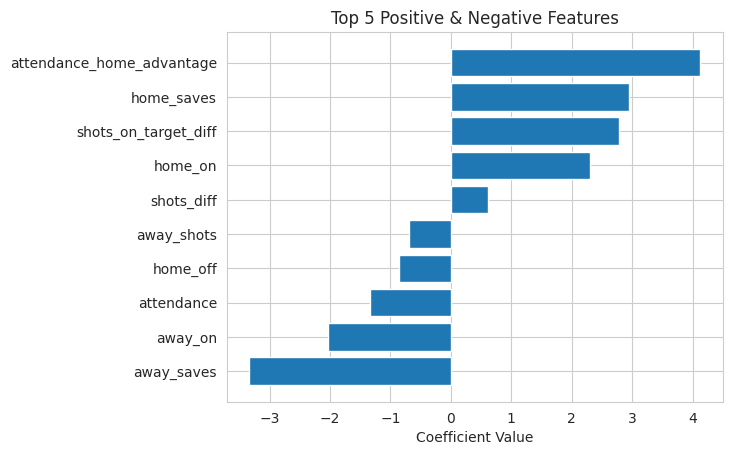

In [29]:
## Baseline Logistic Regression Model
## Features to predict if home team wins. These are variables that describe how the match was played
exclude_cols = [
    'home_win_binary',   ## target
    'away_win_binary',
    'draw_binary',
    'result',
    'result_encoded',
    'goals_home',        ## direct leakage
    'away_goals',
    'goal_diff',         ## derived leakage
    'date',
    'clock',
    'stadium',
    'season'
]

X = df.drop(columns=exclude_cols, errors='ignore')

## keep only numeric + boolean columns
X = X.select_dtypes(include=['int64', 'float64', 'bool'])

## convert bool → int (for scaling)
X = X.astype(float)

y = df['home_win_binary']

## Train on older matches, Test on newer matches. More realworld prediction and model learns
## if games are different in different seasons.
train = df[df['year'] < 2023]
test = df[df['year'] >= 2023]

X_train = train[X.columns]
y_train = train['home_win_binary']

X_test = test[X.columns]
y_test = test['home_win_binary']

## There's variance in variable sizes.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model = LogisticRegression(max_iter=1000)
## Fitting the model to learn relationships like do more shots increase the chance to win?
model.fit(X_train_scaled, y_train)

##Predictions
y_pred = model.predict(X_test_scaled)

## Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Feature importance (coefficients)
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:\n", coef_df)

## Use Probabilities for RMSE comparison
y_prob = model.predict_proba(X_test_scaled)[:, 1]
rmse = np.sqrt(mean_squared_error(y_test, y_prob))

print("RMSE (Logistic Regression):", rmse)

## Get top 5 positive and bottom 5 negative
top_5 = coef_df.sort_values(by='Coefficient', ascending=False).head(5)
bottom_5 = coef_df.sort_values(by='Coefficient', ascending=True).head(5)

## Combine
plot_df = pd.concat([top_5, bottom_5])

## Sort for better visualization
plot_df = plot_df.sort_values(by='Coefficient')

## Plot
plt.figure()
plt.barh(plot_df['Feature'], plot_df['Coefficient'])
plt.xlabel("Coefficient Value")
plt.title("Top 5 Positive & Negative Features")
plt.show()


In [30]:
## RFE = Recursive Feature Elimination - SKLearn Documentation
## This method starts with all features, trains the model,
## removes the weakest feature, and repeats until only the
## chosen number of best features remain.

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

## Base logistic regression model used to rank feature importance
model = LogisticRegression(max_iter=1000)

## Keep the 10 most useful features
rfe = RFE(model, n_features_to_select = 10)

## Fit RFE using the scaled training data
## It learns which variables contribute most to prediction
rfe.fit(X_train_scaled, y_train)

## # Boolean mask: True = selected, False = removed
selected_features = X.columns[rfe.support_]

print(selected_features)

Index(['attendance', 'home_on', 'away_on', 'home_off', 'home_saves',
       'away_saves', 'away_team_3', 'close_match', 'shots_on_target_diff',
       'attendance_home_advantage'],
      dtype='object')


In [31]:
## Logistic Regression with some feature selections

## Features to predict if home team wins. These are variables that describe how the match was played
features = [
    'possession_diff', ## control of the game
    'shots_diff', ## overall attacking pressure
    'shots_on_target_diff', ## how many good chances the team had.
    'fouls_diff', ## discipline - can hurt performance
    'yellow_diff', ## discipline
    'red_diff', ## discipline
    'attendance',  ## crowd size (possible home field advantage?)
    'attendance_high' ## big crowd vs smaller crowd
]

X = df[features]
y = df['home_win_binary']

## Train on older matches, Test on newer matches. More realworld prediction and model learns
## if games are different in different seasons.
train = df[df['year'] < 2023]
test = df[df['year'] >= 2023]

X_train = train[features]
y_train = train['home_win_binary']

X_test = test[features]
y_test = test['home_win_binary']

## There's variance in variable sizes.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model = LogisticRegression(max_iter=1000)
## Fitting the model to learn relationships like do more shots increase the chance to win?
model.fit(X_train_scaled, y_train)

##Predictions
y_pred = model.predict(X_test_scaled)

## Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Feature importance (coefficients)
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\nFeature Importance:\n", coef_df)

## Use Probabilities for RMSE comparison
y_prob = model.predict_proba(X_test_scaled)[:, 1]
rmse = np.sqrt(mean_squared_error(y_test, y_prob))

print("RMSE (Logistic Regression):", rmse)


Accuracy: 0.6759259259259259

Confusion Matrix:
 [[74 35]
 [35 72]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.68      0.68       109
           1       0.67      0.67      0.67       107

    accuracy                           0.68       216
   macro avg       0.68      0.68      0.68       216
weighted avg       0.68      0.68      0.68       216


Feature Importance:
                 Feature  Coefficient
2  shots_on_target_diff     1.905465
6            attendance     0.205469
7       attendance_high     0.094316
3            fouls_diff    -0.049549
4           yellow_diff    -0.093624
5              red_diff    -0.235356
0       possession_diff    -0.289625
1            shots_diff    -0.371910
RMSE (Logistic Regression): 0.45083664532469475


Accuracy: 1.0

Confusion Matrix:
 [[109   0]
 [  0 107]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       107

    accuracy                           1.00       216
   macro avg       1.00      1.00      1.00       216
weighted avg       1.00      1.00      1.00       216


Feature Importance:
                       Feature  Importance
87  attendance_home_advantage    0.558662
82       shots_on_target_diff    0.139648
0                  attendance    0.139327
79                close_match    0.037192
11                  home_pass    0.020341
..                        ...         ...
68               away_team_15    0.000000
76               away_team_23    0.000000
72               away_team_19    0.000000
74               away_team_21    0.000000
75               away_team_22    0.000000

[88 rows x 2 columns]
RMSE (Gradient Boosting): 0.02591783512193

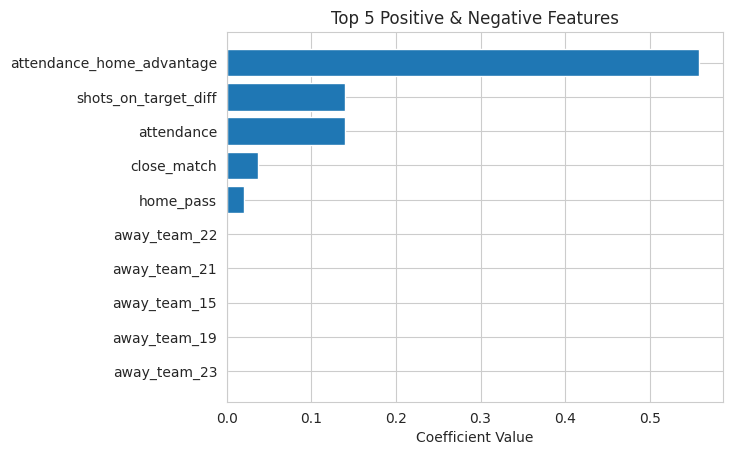

In [32]:
## Baseline Gradient Boosting
## Features to predict if home team wins. These are variables that describe how the match was played
exclude_cols = [
    'home_win_binary',   ## target
    'away_win_binary',
    'draw_binary',
    'result',
    'result_encoded',
    'goals_home',        ## direct leakage
    'away_goals',
    'goal_diff',         ## derived leakage
    'date',
    'clock',
    'stadium',
    'season'
]

X = df.drop(columns=exclude_cols, errors='ignore')

## keep only numeric + boolean columns
X = X.select_dtypes(include=['int64', 'float64', 'bool'])

## convert bool → int (for scaling)
X = X.astype(float)

y = df['home_win_binary']

## Train on older matches, Test on newer matches. More realworld prediction and model learns
## if games are different in different seasons.
train = df[df['year'] < 2023]
test = df[df['year'] >= 2023]

X_train = train[X.columns]
y_train = train['home_win_binary']

X_test = test[X.columns]
y_test = test['home_win_binary']

## There's variance in variable sizes.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error
import numpy as np

model = GradientBoostingClassifier()
## Fitting the model to learn relationships like do more shots increase the chance to win?
model.fit(X_train_scaled, y_train)

##Predictions
y_pred = model.predict(X_test_scaled)

## Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## Feature importance (coefficients)
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", coef_df)

## Use Probabilities for RMSE comparison
y_prob = model.predict_proba(X_test_scaled)[:, 1]
rmse = np.sqrt(mean_squared_error(y_test, y_prob))

print("RMSE (Gradient Boosting):", rmse)

## Get top 5 positive and bottom 5 negative
top_5 = coef_df.head(5)
bottom_5 = coef_df.tail(5)

## Sort for better visualization
plot_df = pd.concat([top_5, bottom_5]).sort_values(by='Importance')

## Plot
plt.figure()
plt.barh(plot_df['Feature'], plot_df['Importance'])
plt.xlabel("Coefficient Value")
plt.title("Top 5 Positive & Negative Features")
plt.show()

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

## Gradient boosting model used for feature ranking
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

## Keep the top 10 features
rfe_gb = RFE(
    estimator=gb_model,
    n_features_to_select=10
)

## No scaling needed for gradient boosting
rfe_gb.fit(X_train, y_train)

selected_features_gb = X.columns[rfe_gb.support_]

print("Selected Features for Gradient Boosting:")
print(selected_features_gb)

Selected Features for Gradient Boosting:
Index(['attendance', 'home_on', 'home_pass', 'away_duels', 'home_saves',
       'away_saves', 'away_team_25', 'close_match', 'shots_on_target_diff',
       'attendance_home_advantage'],
      dtype='object')


Gradient Boosting RFE is more inline with feature selection. For reasons mentioned above, I will keep the same features for comparison purposes.

In [34]:
## Gradient Boosting with selected features
features = [
    'possession_diff',
    'shots_diff',
    'shots_on_target_diff',
    'fouls_diff',
    'yellow_diff',
    'red_diff',
    'attendance',
    'attendance_high'
]

X = df[features]
y = df['home_win_binary']

train = df[df['year'] < 2023]
test = df[df['year'] >= 2023]

X_train = train[features]
y_train = train['home_win_binary']

X_test = test[features]
y_test = test['home_win_binary']

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

import pandas as pd

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance_df)

Accuracy: 0.6898148148148148

Confusion Matrix:
 [[79 30]
 [37 70]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.72      0.70       109
           1       0.70      0.65      0.68       107

    accuracy                           0.69       216
   macro avg       0.69      0.69      0.69       216
weighted avg       0.69      0.69      0.69       216


Feature Importance:
                 Feature  Importance
2  shots_on_target_diff    0.585194
6            attendance    0.131787
0       possession_diff    0.107852
1            shots_diff    0.094683
3            fouls_diff    0.028208
5              red_diff    0.026732
4           yellow_diff    0.023719
7       attendance_high    0.001825


Logistic Regression Improvements - Removed year, implemented Time-Based Cross-Validation, c = 10

In [35]:
## Logistic Regression with selected Features and fine tuning
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

features = [
    'possession_diff',
    'shots_diff',
    'shots_on_target_diff',
    'fouls_diff',
    'yellow_diff',
    'red_diff',
    'attendance',
    'attendance_high'
]

X = df[features]
y = df['home_win_binary']

## Sort by year so time order stays the same
df = df.sort_values(['year', 'date']).reset_index(drop = True)

X = df[features]
y = df['home_win_binary']

## Time-based cross-validation
tscv = TimeSeriesSplit(n_splits=4)

## Slight tuning...
model = LogisticRegression(
    max_iter=1000,
    C=10,          ## Tried 0.1, 1, 10 - Chose best results.
    solver='lbfgs',
    class_weight = 'balanced'
)

accuracies = []
all_y_true = []
all_y_pred = []
cv_scores = []
coef_list = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    ## Should be scaling each fold
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    score = model.score(X_test_scaled, y_test)
    cv_scores.append(score)
    coef_list.append(model.coef_[0])

    accuracies.append(accuracy_score(y_test, y_pred))
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

coef_array = np.array(coef_list)

## Average across folds
avg_coef = np.mean(coef_array, axis=0)

coef_df = pd.DataFrame({
    'Feature': features,
    'Average Coefficient': avg_coef
}).sort_values(by='Average Coefficient', ascending=False)

print("CV Accuracy Scores:", accuracies)
print("Average Accuracy:", np.mean(accuracies))

print("\nConfusion Matrix:\n", confusion_matrix(all_y_true, all_y_pred))
print("\nClassification Report:\n", classification_report(all_y_true, all_y_pred))

print("\nAverage Feature Importance:\n", coef_df)



CV Accuracy Scores: [0.7543859649122807, 0.6973684210526315, 0.7368421052631579, 0.6885964912280702]
Average Accuracy: 0.7192982456140351

Confusion Matrix:
 [[349 156]
 [100 307]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.69      0.73       505
           1       0.66      0.75      0.71       407

    accuracy                           0.72       912
   macro avg       0.72      0.72      0.72       912
weighted avg       0.73      0.72      0.72       912


Average Feature Importance:
                 Feature  Average Coefficient
2  shots_on_target_diff             2.070258
7       attendance_high             0.291498
3            fouls_diff            -0.074981
6            attendance            -0.122296
4           yellow_diff            -0.150617
5              red_diff            -0.208871
0       possession_diff            -0.280319
1            shots_diff            -0.534535


Gradient Boosting Improvements

In [36]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

features = [
    'possession_diff',
    'shots_diff',
    'shots_on_target_diff',
    'fouls_diff',
    'yellow_diff',
    'red_diff',
    'attendance',
    'attendance_high'
]

## Removed 'year' as a predictor because time ordering is already handled
## through TimeSeriesSplit, and including it as a feature adds little value
## while risking the model learning season labels rather than match behavior.

df = df.sort_values(['year', 'date']).reset_index(drop=True)

X = df[features]
y = df['home_win_binary']

## Time-based CV
tscv = TimeSeriesSplit(n_splits=4)

## Tuned Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=200,     ## more trees
    learning_rate=0.05,   ## slower learning = could improve results
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,        ## helps reduce overfitting
    random_state=42
)

accuracies = []
all_y_true = []
all_y_pred = []
importance_list = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    gb_model.fit(X_train, y_train)
    y_pred = gb_model.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    # Store feature importances
    importance_list.append(gb_model.feature_importances_)

# Results
print("CV Accuracy Scores:", accuracies)
print("Average Accuracy:", np.mean(accuracies))

print("\nConfusion Matrix:\n", confusion_matrix(all_y_true, all_y_pred))
print("\nClassification Report:\n", classification_report(all_y_true, all_y_pred))

## Average feature importance
avg_importance = np.mean(np.array(importance_list), axis=0)

importance_df = pd.DataFrame({
    'Feature': features,
    'Average Importance': avg_importance
}).sort_values(by='Average Importance', ascending=False)

print("\nAverage Feature Importance:\n", importance_df)

CV Accuracy Scores: [0.7149122807017544, 0.7412280701754386, 0.7149122807017544, 0.6710526315789473]
Average Accuracy: 0.7105263157894737

Confusion Matrix:
 [[400 105]
 [159 248]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.79      0.75       505
           1       0.70      0.61      0.65       407

    accuracy                           0.71       912
   macro avg       0.71      0.70      0.70       912
weighted avg       0.71      0.71      0.71       912


Average Feature Importance:
                 Feature  Average Importance
2  shots_on_target_diff            0.458043
0       possession_diff            0.185204
1            shots_diff            0.134075
3            fouls_diff            0.076574
6            attendance            0.070579
4           yellow_diff            0.055503
5              red_diff            0.018268
7       attendance_high            0.001754


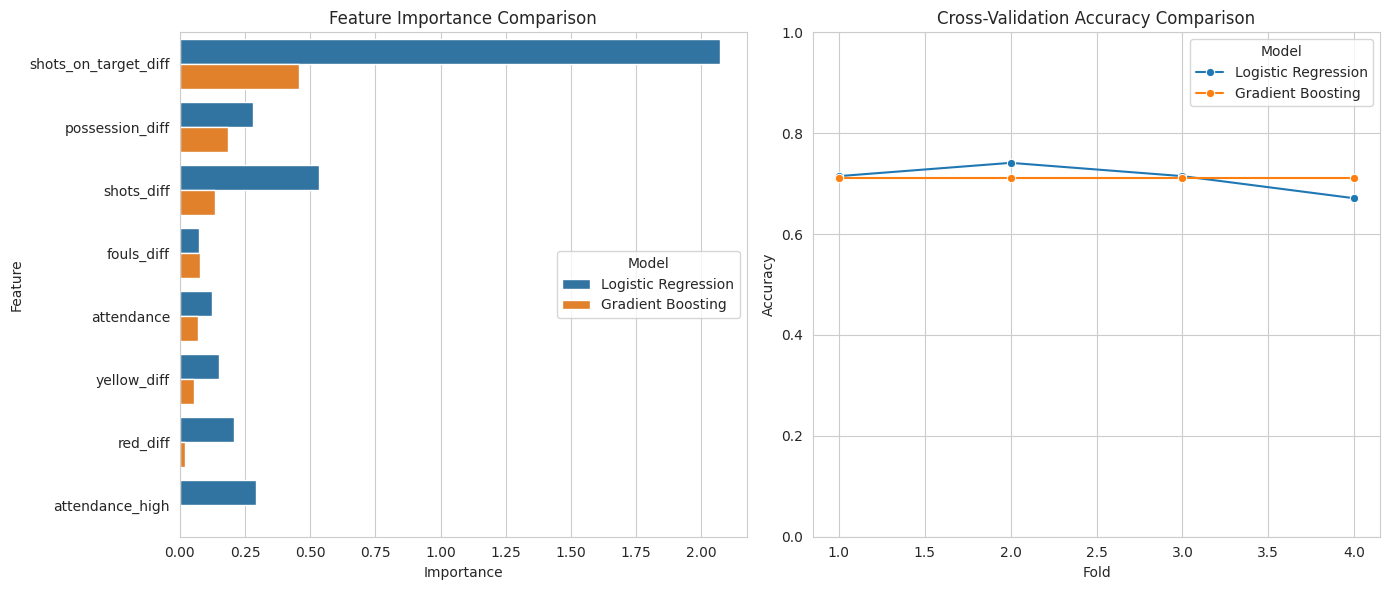

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Logistic Regression
lr_importance = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(avg_coef),   ## absolute value
    'Model': 'Logistic Regression'
})

## Gradient Boosting
gb_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': avg_importance,
    'Model': 'Gradient Boosting'
})

## Combine for plotting
importance_combined = pd.concat([lr_importance, gb_importance_df], axis=0)

## Sort features by average importance (optional: by GB for visual clarity)
feature_order = gb_importance_df.sort_values(by='Importance', ascending=False)['Feature']

## Accuracy for plotting
accuracy_df = pd.DataFrame({
    'Fold': np.arange(1, 5),
    'Logistic Regression': accuracies,  # from your LR code
    'Gradient Boosting': np.mean(accuracies)  # Replace with GB accuracies list if different
})

## Reshape for seaborn
accuracy_long = accuracy_df.melt(id_vars='Fold', var_name='Model', value_name='Accuracy')


## Plot
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

## Feature Importance Bar Chart
sns.barplot(
    data=importance_combined,
    x='Importance',
    y='Feature',
    hue='Model',
    order=feature_order,
    ax=axes[0]
)
axes[0].set_title("Feature Importance Comparison")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")
axes[0].legend(title='Model',loc='right')

## Accuracy per Fold Line Chart
sns.lineplot(
    data=accuracy_long,
    x='Fold',
    y='Accuracy',
    hue='Model',
    marker='o',
    ax=axes[1]
)
axes[1].set_title("Cross-Validation Accuracy Comparison")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].legend(title='Model')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("whitegrid")

## Features (final selected)
features = [
    'possession_diff',
    'shots_diff',
    'shots_on_target_diff',
    'fouls_diff',
    'yellow_diff',
    'red_diff',
    'attendance',
    'attendance_high'
]

## Logistic Regression
avg_coef = [ -0.280319, -0.534535, 2.070258, -0.074981, -0.150617, -0.208871, -0.122296, 0.291498 ]  ## absolute value will be used
lr_accuracies = [0.7543859649122807, 0.6973684210526315, 0.7368421052631579, 0.6885964912280702]
lr_holdout = 0.676  ## holdout accuracy

## Gradient Boosting
avg_importance = [0.185204, 0.134075, 0.458043, 0.076574, 0.055503, 0.018268, 0.070579, 0.001754]
gb_accuracies = [0.7149122807017544, 0.7412280701754386, 0.7149122807017544, 0.6710526315789473]
gb_holdout = 0.6898  ## holdout accuracy


## Logistic Regression Feature Importance

lr_importance = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(avg_coef)  # absolute value
})

feature_order_lr = lr_importance.sort_values(by='Importance', ascending=False)['Feature']

plt.figure(figsize=(8,6))
sns.barplot(
    data=lr_importance,
    x='Importance',
    y='Feature',
    order=feature_order_lr,
    color='skyblue'
)
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Gradient Boosting Feature Importance

gb_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': avg_importance,
})

feature_order_gb = gb_importance_df.sort_values(by='Importance', ascending=False)['Feature']

plt.figure(figsize=(8,6))
sns.barplot(
    data=gb_importance_df,
    x='Importance',
    y='Feature',
    order=feature_order_gb,
    color='salmon'
)
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Logistic Regression Accuracy per Fold

accuracy_df = pd.DataFrame({
    'Fold': np.arange(1, 5),
    'Logistic Regression': lr_accuracies,
})

accuracy_long = accuracy_df.melt(id_vars='Fold', var_name='Model', value_name='Accuracy')

plt.figure(figsize=(8,6))
sns.lineplot(
    data=accuracy_long,
    x='Fold',
    y='Accuracy',
    hue='Model',
    marker='o'
)
## Add holdout accuracy line
plt.axhline(y=lr_holdout, color='blue', linestyle='-', label=f'LR Holdout Accuracy ({lr_holdout:.2f})')

plt.title("Logistic Regression Cross-Validation Accuracy")
plt.ylim(0,1)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


## Gradient Boosting Accuracy per Fold

gb_accuracy_df = pd.DataFrame({
    'Fold': np.arange(1, 5),
    'Gradient Boosting': gb_accuracies
})

gb_accuracy_long = gb_accuracy_df.melt(id_vars='Fold', var_name='Model', value_name='Accuracy')

plt.figure(figsize=(8,6))
sns.lineplot(
    data=gb_accuracy_long,
    x='Fold',
    y='Accuracy',
    hue='Model',
    marker='o',
    color='salmon'
)
## Add holdout accuracy line
plt.axhline(y=gb_holdout, color='red', linestyle='-', label=f'GB Holdout Accuracy ({gb_holdout:.2f})')

plt.title("Gradient Boosting Cross-Validation Accuracy")
plt.ylim(0,1)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()